<a href="https://colab.research.google.com/github/derVian/datascience/blob/main/datascienceML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
model = XGBRegressor(random_state=42)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [44]:
file_path = '/content/drive/MyDrive/Colab_Data/solar2022uncleaned.csv'
dfp1 = pd.read_csv(file_path, skiprows=1, header=1)

In [46]:
print(dfp1.head())
print(dfp1.describe())

   Year  Month  Day  Hour  Minute  Temperature  Clearsky DHI  Clearsky DNI  \
0  2022      1    1     0      30          4.9             0             0   
1  2022      1    1     1      30          5.2             0             0   
2  2022      1    1     2      30          5.3             0             0   
3  2022      1    1     3      30          5.3             0             0   
4  2022      1    1     4      30          5.3             0             0   

   Clearsky GHI  Cloud Type  ...  DNI  GHI  Solar Zenith Angle  \
0             0           1  ...    0    0              159.08   
1             0           4  ...    0    0              161.96   
2             0           0  ...    0    0              157.00   
3             0           0  ...    0    0              147.66   
4             0           4  ...    0    0              136.82   

   Precipitable Water  Surface Albedo  Fill Flag  Dew Point  Asymmetry  \
0                 1.4            0.17          0       -0.3 

In [47]:
dfp1['Date'] = pd.to_datetime(dfp1[['Year', 'Month', 'Day']])
dfp1['day_ofyear'] = dfp1['Date'].dt.dayofyear
print(dfp1.head())

   Year  Month  Day  Hour  Minute  Temperature  Clearsky DHI  Clearsky DNI  \
0  2022      1    1     0      30          4.9             0             0   
1  2022      1    1     1      30          5.2             0             0   
2  2022      1    1     2      30          5.3             0             0   
3  2022      1    1     3      30          5.3             0             0   
4  2022      1    1     4      30          5.3             0             0   

   Clearsky GHI  Cloud Type  ...  Solar Zenith Angle  Precipitable Water  \
0             0           1  ...              159.08                 1.4   
1             0           4  ...              161.96                 0.5   
2             0           0  ...              157.00                 0.5   
3             0           0  ...              147.66                 0.5   
4             0           4  ...              136.82                 0.5   

   Surface Albedo  Fill Flag  Dew Point  Asymmetry  Aerosol Optical Depth 

In [53]:
dfp1['Time'] = dfp1['Hour'].astype(str).str.zfill(2) + ':' + dfp1['Minute'].astype(str).str.zfill(2)
print(dfp1[['Hour', 'Minute', 'Time']].head())

   Hour  Minute   Time
0     0      30  00:30
1     1      30  01:30
2     2      30  02:30
3     3      30  03:30
4     4      30  04:30


/tmp/ipykernel_303/1014153148.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp1['Time'] = dfp1['Hour'].astype(str).str.zfill(2) + ':' + dfp1['Minute'].astype(str).str.zfill(2)


In [52]:
dfp1['is_daytime'] = (dfp1['GHI'] > 0).astype(int)
print(dfp1[['GHI', 'is_daytime']].head(25))

    GHI  is_daytime
0     0           0
1     0           0
2     0           0
3     0           0
4     0           0
5     0           0
6     0           0
7     0           0
8     0           0
9    18           1
10  141           1
11  219           1
12  296           1
13  464           1
14  272           1
15  335           1
16  203           1
17   23           1
18    0           0
19    0           0
20    0           0
21    0           0
22    0           0
23    0           0
24    0           0


/tmp/ipykernel_303/1841603949.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp1['is_daytime'] = (dfp1['GHI'] > 0).astype(int)


In [54]:
desired_leading_columns = ["Time", "day_ofyear",'is_daytime', "GHI"]

# Get all columns currently in dfp1
all_columns = dfp1.columns.tolist()

# Filter out the desired leading columns from the rest
remaining_columns = [col for col in all_columns if col not in desired_leading_columns]

# Create the new ordered list of columns
new_column_order = desired_leading_columns + remaining_columns

# Reindex the DataFrame with the new column order
dfp1 = dfp1[new_column_order]

print(dfp1.head())

    Time  day_ofyear  is_daytime  GHI  Year  Month  Day  Hour  Minute  \
0  00:30           1           0    0  2022      1    1     0      30   
1  01:30           1           0    0  2022      1    1     1      30   
2  02:30           1           0    0  2022      1    1     2      30   
3  03:30           1           0    0  2022      1    1     3      30   
4  04:30           1           0    0  2022      1    1     4      30   

   Temperature  ...  DNI  Solar Zenith Angle  Precipitable Water  \
0          4.9  ...    0              159.08                 1.4   
1          5.2  ...    0              161.96                 0.5   
2          5.3  ...    0              157.00                 0.5   
3          5.3  ...    0              147.66                 0.5   
4          5.3  ...    0              136.82                 0.5   

   Surface Albedo  Fill Flag  Dew Point  Asymmetry  Aerosol Optical Depth  \
0            0.17          0       -0.3       0.67                  0.071  

In [55]:
new_df = dfp1[['Time', 'day_ofyear', 'is_daytime', 'Temperature', 'Clearsky GHI','GHI']].copy()
print(new_df.head())

    Time  day_ofyear  is_daytime  Temperature  Clearsky GHI  GHI
0  00:30           1           0          4.9             0    0
1  01:30           1           0          5.2             0    0
2  02:30           1           0          5.3             0    0
3  03:30           1           0          5.3             0    0
4  04:30           1           0          5.3             0    0


In [56]:
new_df['GHI_lag1'] = new_df['GHI'].shift(1)
new_df['GHI_lag24'] = new_df['GHI'].shift(24)
print(new_df.head(30))

     Time  day_ofyear  is_daytime  Temperature  Clearsky GHI  GHI  GHI_lag1  \
0   00:30           1           0          4.9             0    0       NaN   
1   01:30           1           0          5.2             0    0       0.0   
2   02:30           1           0          5.3             0    0       0.0   
3   03:30           1           0          5.3             0    0       0.0   
4   04:30           1           0          5.3             0    0       0.0   
5   05:30           1           0          5.2             0    0       0.0   
6   06:30           1           0          5.1             0    0       0.0   
7   07:30           1           0          4.7             0    0       0.0   
8   08:30           1           0          5.2             0    0       0.0   
9   09:30           1           1          7.7            96   18       0.0   
10  10:30           1           1         11.3           245  141      18.0   
11  11:30           1           1         13.9      

In [57]:
new_df['GHI_rolling_mean_3h'] = new_df['GHI'].shift(1).rolling(window=3).mean()
new_df['GHI_rolling_std_3h'] = new_df['GHI'].rolling(window=3).std().shift(1)

new_df['GHI_rolling_mean_6h'] = new_df['GHI'].shift(1).rolling(window=6).mean()
new_df['GHI_rolling_std_6h'] = new_df['GHI'].shift(1).rolling(window=6).std()

new_df['GHI_rolling_mean_12h'] = new_df['GHI'].shift(1).rolling(window=12).mean()
new_df['GHI_rolling_std_12h'] = new_df['GHI'].shift(1).rolling(window=12).std()

print(new_df.head(30))

     Time  day_ofyear  is_daytime  Temperature  Clearsky GHI  GHI  GHI_lag1  \
0   00:30           1           0          4.9             0    0       NaN   
1   01:30           1           0          5.2             0    0       0.0   
2   02:30           1           0          5.3             0    0       0.0   
3   03:30           1           0          5.3             0    0       0.0   
4   04:30           1           0          5.3             0    0       0.0   
5   05:30           1           0          5.2             0    0       0.0   
6   06:30           1           0          5.1             0    0       0.0   
7   07:30           1           0          4.7             0    0       0.0   
8   08:30           1           0          5.2             0    0       0.0   
9   09:30           1           1          7.7            96   18       0.0   
10  10:30           1           1         11.3           245  141      18.0   
11  11:30           1           1         13.9      

In [60]:
new_df.dropna(inplace=True)
print(new_df.head())

     Time  day_ofyear  is_daytime  Temperature  Clearsky GHI  GHI  GHI_lag1  \
24  00:30           2           0          7.2             0    0       0.0   
25  01:30           2           0          7.0             0    0       0.0   
26  02:30           2           0          7.0             0    0       0.0   
27  03:30           2           0          7.1             0    0       0.0   
28  04:30           2           0          7.3             0    0       0.0   

    GHI_lag24  GHI_rolling_mean_3h  GHI_rolling_std_3h  GHI_rolling_mean_6h  \
24        0.0                  0.0                 0.0                  0.0   
25        0.0                  0.0                 0.0                  0.0   
26        0.0                  0.0                 0.0                  0.0   
27        0.0                  0.0                 0.0                  0.0   
28        0.0                  0.0                 0.0                  0.0   

    GHI_rolling_std_6h  GHI_rolling_mean_12h  GHI_

In [64]:
new_df['Time'] = pd.to_datetime(new_df['Time'], format='%H:%M').dt.time
new_df["hour"] = new_df["Time"].apply(lambda x: x.hour)
new_df["hour_sin"] = np.sin(2*np.pi*new_df["hour"]/24)
new_df["hour_cos"] = np.cos(2*np.pi*new_df["hour"]/24)
new_df["doy_sin"] = np.sin(2*np.pi*new_df["day_ofyear"]/365)
new_df["doy_cos"] = np.cos(2*np.pi*new_df["day_ofyear"]/365)
new_df.drop(['hour', 'day_ofyear'], axis=1, inplace=True)

ValueError: unconverted data remains when parsing with format "%H:%M": ":00", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [66]:

new_df = new_df.drop(columns=['Time'])
print(new_df.head(25))

    is_daytime  Temperature  Clearsky GHI  GHI  GHI_lag1  GHI_lag24  \
24           0          7.2             0    0       0.0        0.0   
25           0          7.0             0    0       0.0        0.0   
26           0          7.0             0    0       0.0        0.0   
27           0          7.1             0    0       0.0        0.0   
28           0          7.3             0    0       0.0        0.0   
29           0          7.4             0    0       0.0        0.0   
30           0          7.3             0    0       0.0        0.0   
31           0          7.1             0    0       0.0        0.0   
32           0          7.4             0    0       0.0        0.0   
33           1          8.8            89   28       0.0       18.0   
34           1         11.0           235  109      28.0      141.0   
35           1         13.0           355  248     109.0      219.0   
36           1         14.7           429  429     248.0      296.0   
37    

## Split Data


In [67]:
X = new_df.drop('GHI', axis=1)
y = new_df['GHI']

print("X head:\n", X.head())
print("\ny head:\n", y.head())
print("\nX shape:", X.shape)
print("y shape:", y.shape)

X head:
     is_daytime  Temperature  Clearsky GHI  GHI_lag1  GHI_lag24  \
24           0          7.2             0       0.0        0.0   
25           0          7.0             0       0.0        0.0   
26           0          7.0             0       0.0        0.0   
27           0          7.1             0       0.0        0.0   
28           0          7.3             0       0.0        0.0   

    GHI_rolling_mean_3h  GHI_rolling_std_3h  GHI_rolling_mean_6h  \
24                  0.0                 0.0                  0.0   
25                  0.0                 0.0                  0.0   
26                  0.0                 0.0                  0.0   
27                  0.0                 0.0                  0.0   
28                  0.0                 0.0                  0.0   

    GHI_rolling_std_6h  GHI_rolling_mean_12h  GHI_rolling_std_12h  hour_sin  \
24                 0.0            132.750000           170.397463  0.000000   
25                 0.0     

## Initialize XGBoost Regressor

### Subtask:
Initialize an XGBoost Regressor model.


In [93]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6988, 15)
X_test shape: (1748, 15)
y_train shape: (6988,)
y_test shape: (1748,)


In [95]:
model.fit(X_train, y_train)
print("XGBoost Regressor model trained successfully.")

XGBoost Regressor model trained successfully.


In [71]:
y_pred = model.predict(X_test)
print("First 10 predictions:\n", y_pred[:10])

First 10 predictions:
 [ 2.6775964e+02 -1.3646846e+00  6.5198112e-01  3.4006769e+02
 -6.3196644e-02 -1.9178632e+00  2.1131381e+02  1.4129349e+00
  6.7107552e-01  9.4798865e+02]


## Evaluate Model

In [97]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Absolute Error (MAE): 33.84
Mean Squared Error (MSE): 5378.08
R-squared (R2) Score: 0.93


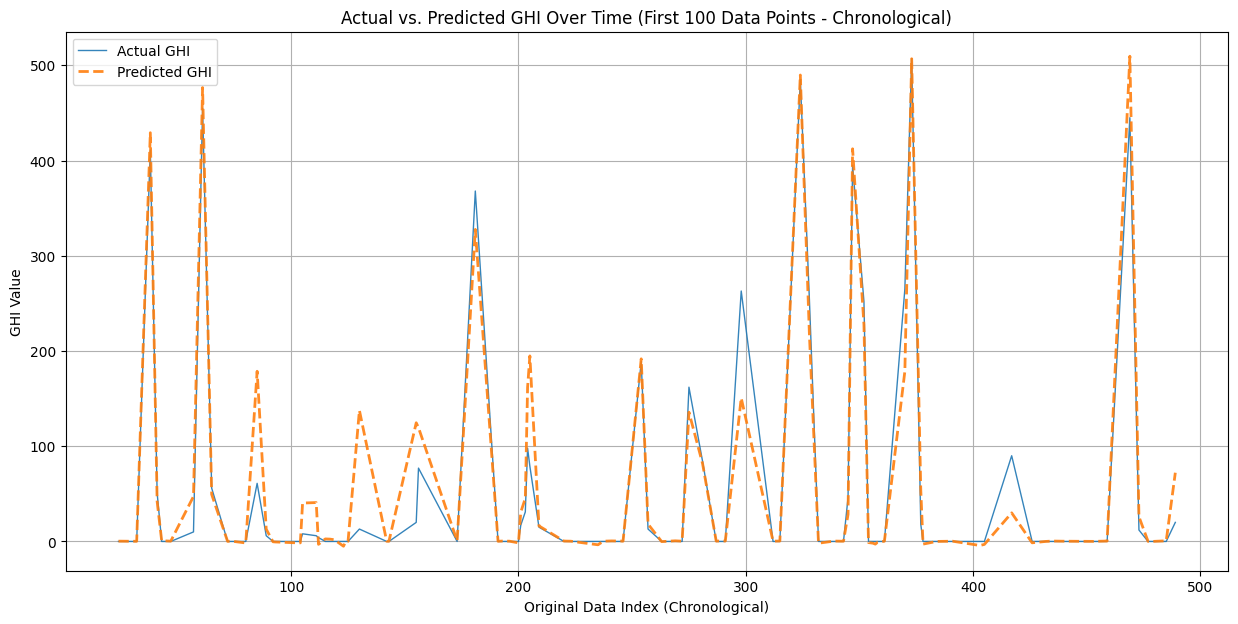

Line plot of actual vs. predicted GHI generated for a chronological subset of data.


In [90]:
# Sort y_test by its index to get chronological order
y_test_sorted = y_test.sort_index()
# Align y_pred with the sorted y_test indices
y_pred_sorted = pd.Series(y_pred, index=y_test.index).sort_index()

plt.figure(figsize=(15, 7))
# Plotting a subset of the data for better visibility
plt.plot(y_test_sorted.index[:100], y_test_sorted[:100], label='Actual GHI', alpha=0.9, linewidth=1)
plt.plot(y_pred_sorted.index[:100], y_pred_sorted[:100], label='Predicted GHI', alpha=0.9, linestyle='--', linewidth=2)
plt.title('Actual vs. Predicted GHI Over Time (First 100 Data Points - Chronological)')
plt.xlabel('Original Data Index (Chronological)')
plt.ylabel('GHI Value')
plt.legend()
plt.grid(True)
plt.show()
print("Line plot of actual vs. predicted GHI generated for a chronological subset of data.")

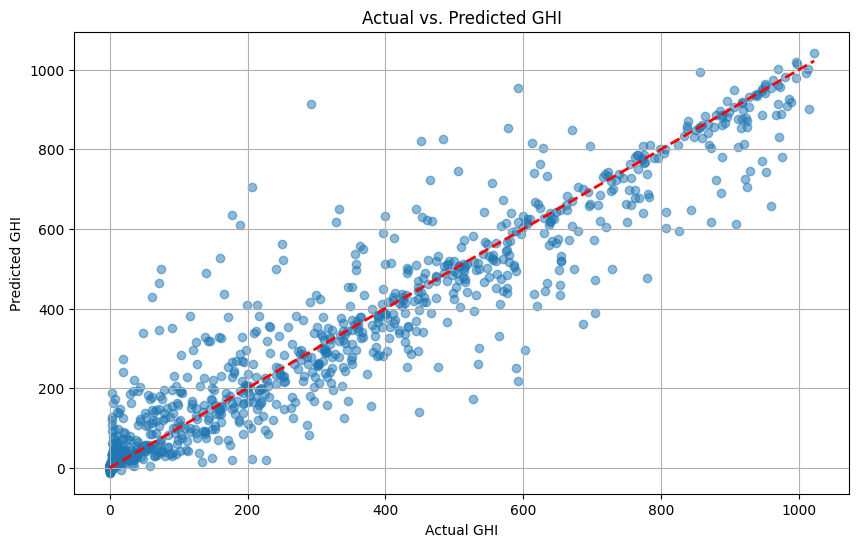

Scatter plot of actual vs. predicted GHI generated.


In [75]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual GHI')
plt.ylabel('Predicted GHI')
plt.title('Actual vs. Predicted GHI')
plt.grid(True)
plt.show()
print("Scatter plot of actual vs. predicted GHI generated.")

## Generate Residual Plot
Generate a residual plot by plotting the differences between actual and predicted values (residuals) against the predicted values. This helps in identifying patterns in the errors.


In [76]:
residuals = y_test - y_pred
print("First 10 residuals:\n", residuals.head(10))

First 10 residuals:
 1166    -84.759644
1441      1.364685
7036     -0.651981
1311    113.932312
1725      0.063197
1782      1.917863
1257     30.686188
3024     -1.412935
5446     -0.671076
2413    -42.988647
Name: GHI, dtype: float64


**Reasoning**:
Now that the residuals are calculated, I will create a scatter plot of the predicted values against the residuals, add a horizontal line at y=0, label the axes, and add a title, as instructed, to generate the residual plot.



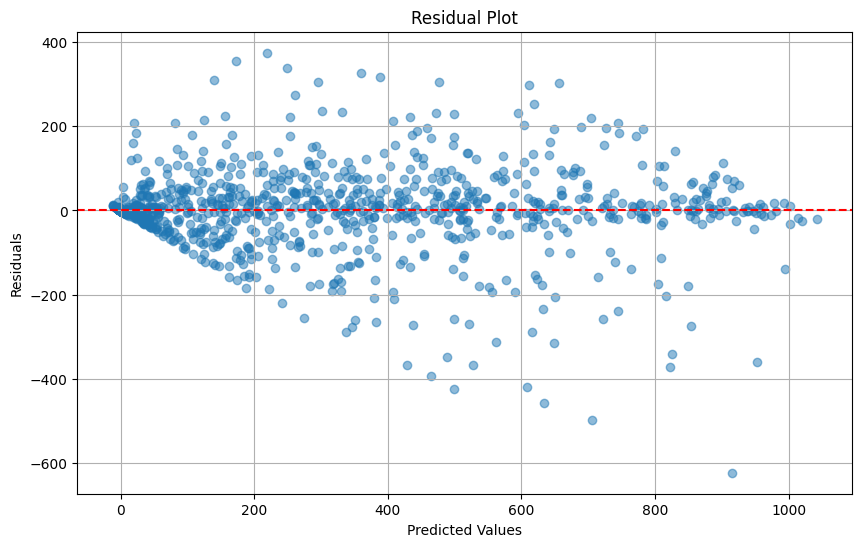

Residual plot generated.


In [77]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()
print("Residual plot generated.")

MAE     33.836319
RMSE    73.335388
dtype: float64


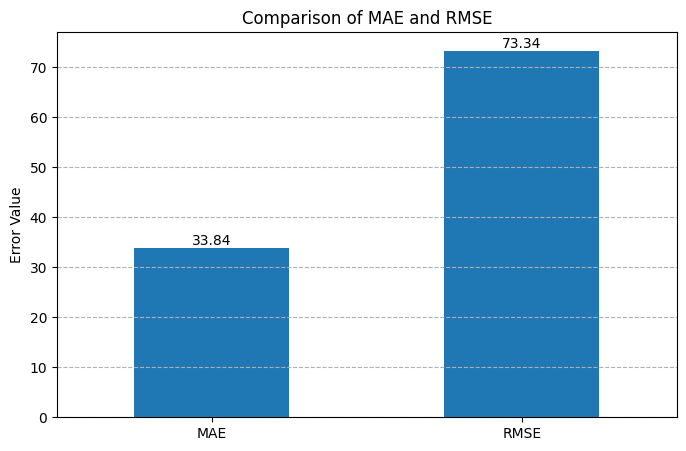

Bar plot comparing MAE and RMSE generated with values.


In [84]:
error_metrics = pd.Series({'MAE': mae, 'RMSE': rmse})
print(error_metrics)
error_metrics.plot.bar(figsize=(8, 5))
plt.title('Comparison of MAE and RMSE')
plt.ylabel('Error Value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')

# Add text annotations for values
for index, value in enumerate(error_metrics):
    plt.text(index, value, f'{value:.2f}', ha='center', va='bottom')

plt.show()
print("Bar plot comparing MAE and RMSE generated with values.")

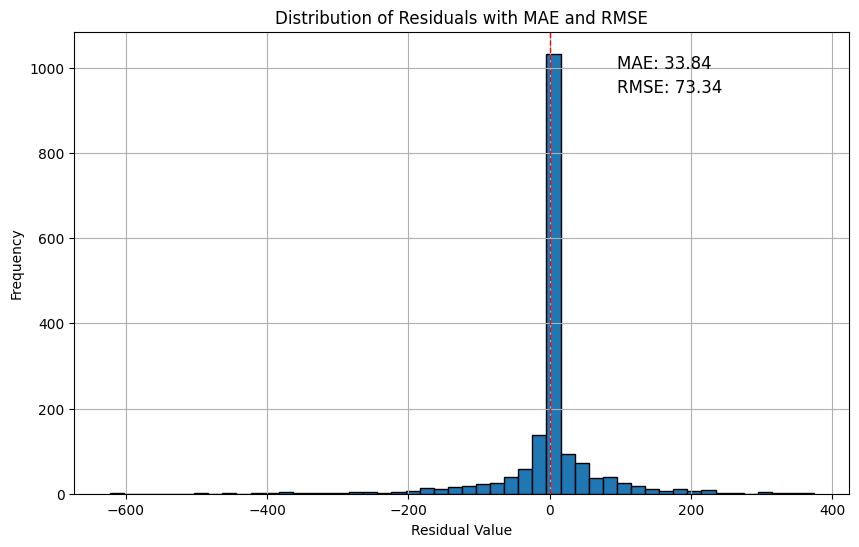

Histogram of residuals with MAE and RMSE generated.


In [78]:
rmse = np.sqrt(mse)

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals with MAE and RMSE')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero Residual')
plt.text(0.70, 0.95, f'MAE: {mae:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.70, 0.90, f'RMSE: {rmse:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.grid(True)
plt.show()
print("Histogram of residuals with MAE and RMSE generated.")

## Summary:

### Data Analysis Key Findings

*   The Mean Absolute Error (MAE) was calculated to be 33.836319.
*   The Root Mean Squared Error (RMSE) was calculated to be 73.335388.
